In [1]:
!pip install kagglehub
import numpy as np
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
!pip install missingno
import missingno as msno
from datetime import date
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [2]:
df = pd.read_csv("vmCloud_data.csv")

df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881,78.951,164.776,287.809,7527.000,69.346,0.554,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.519,29.902,NaN,362.274,5348.000,41.396,0.350,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709,203.675,231.468,5483.000,24.603,0.796,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488,88.101,NaN,195.640,5876.000,16.457,0.530,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365,NaN,NaN,359.452,3361.000,55.308,0.352,NaN,medium,waiting


In [3]:
def grab_col_names(dataframe, cat_th=10, car_th=20):


    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2000000
Variables: 12
cat_cols: 3
num_cols: 7
cat_but_car: 2
num_but_cat: 0


In [4]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

low, up =outlier_thresholds(df, num_cols)

In [5]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False
    
for col in num_cols:
    print(col, check_outlier(df, col))

cpu_usage False
memory_usage False
network_traffic False
power_consumption False
num_executed_instructions False
execution_time False
energy_efficiency False


In [6]:
df.isnull().sum().sum()

np.int64(2399860)

In [7]:
df.shape

(2000000, 12)

In [8]:
df = df[df.isnull().sum(axis=1) < 5]

# timestamp ve vm_id boş olanları temizleme
df = df.dropna(subset=['timestamp', 'vm_id'])

# Yeni boyut kontrolü
print(f"Yeni veri seti boyutu: {df.shape}")

# Eksik değer analizi tekrar yapalım
def missing_values_table(dataframe):
    missing_values = dataframe.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    missing_percentage = (missing_values / len(dataframe)) * 100
    missing_df = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percentage})
    missing_df = missing_df.sort_values(by="Missing Values", ascending=False)
    return missing_df

# Temizlikten sonra kalan eksik değerleri görelim
missing_values = missing_values_table(df)
print(missing_values)

Yeni veri seti boyutu: (1616235, 12)
                           Missing Values  Percentage
memory_usage                       161204       9.974
task_status                        160935       9.957
power_consumption                  160769       9.947
energy_efficiency                  160399       9.924
num_executed_instructions          160359       9.922
task_type                          160277       9.917
network_traffic                    160182       9.911
execution_time                     160127       9.907
task_priority                      160094       9.905
cpu_usage                          160060       9.903


In [9]:
def missing_and_zero_values_table(dataframe):

    missing_values = dataframe.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    missing_percentage = (missing_values / len(dataframe)) * 100
    

    zero_values = (dataframe == 0).sum()
    zero_values = zero_values[zero_values > 0]


    missing_df = pd.DataFrame({"Missing Values": missing_values, 
                               "Percentage (%)": missing_percentage})
    
    zero_df = pd.DataFrame({"Zero Values": zero_values})


    final_df = pd.concat([missing_df, zero_df], axis=1).fillna(0)
    final_df = final_df.sort_values(by="Missing Values", ascending=False)

    return final_df

result_df = missing_and_zero_values_table(df)
print(result_df)

                           Missing Values  Percentage (%)  Zero Values
memory_usage                       161204           9.974        0.000
task_status                        160935           9.957        0.000
power_consumption                  160769           9.947        0.000
energy_efficiency                  160399           9.924        0.000
num_executed_instructions          160359           9.922      170.000
task_type                          160277           9.917        0.000
network_traffic                    160182           9.911        0.000
execution_time                     160127           9.907        0.000
task_priority                      160094           9.905        0.000
cpu_usage                          160060           9.903        0.000


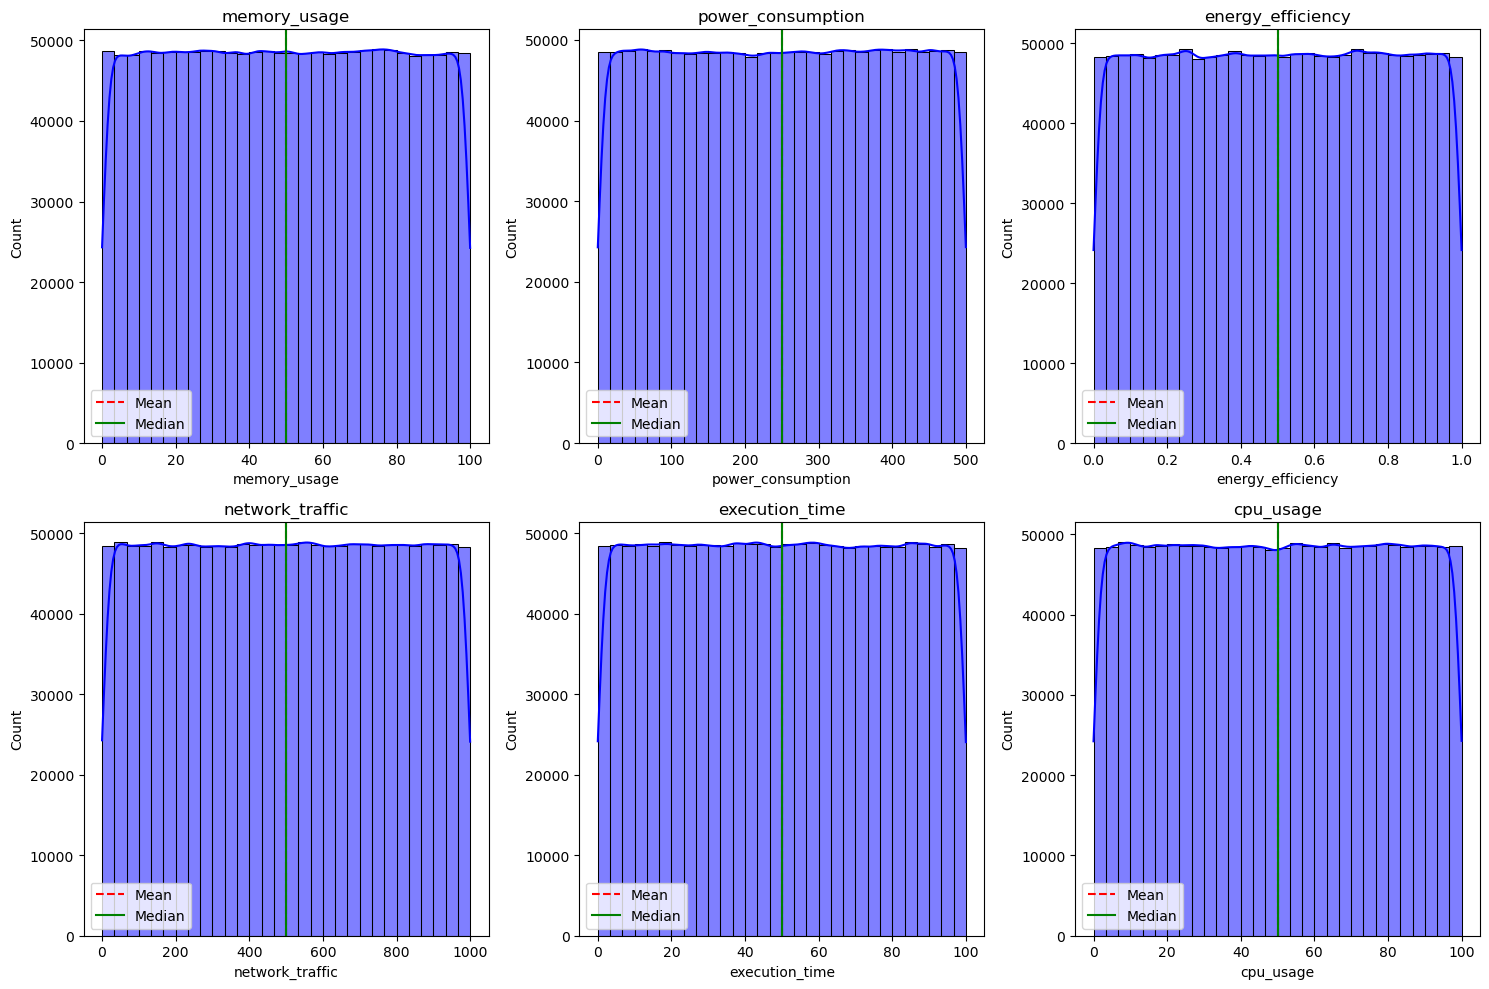

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    "memory_usage", "power_consumption", "energy_efficiency",
    "network_traffic", "execution_time", "cpu_usage"
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='green', linestyle='-', label='Median')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Mean ile doldurulacak değişkenler
mean_fill_cols = ["memory_usage", "energy_efficiency", "network_traffic", "execution_time", "cpu_usage"]

# Mean ile doldur
for col in mean_fill_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\1463880351.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [12]:
df = df.dropna(subset=['power_consumption'])

In [13]:
df.isnull().sum()

vm_id                             0
timestamp                         0
cpu_usage                         0
memory_usage                      0
network_traffic                   0
power_consumption                 0
num_executed_instructions    144791
execution_time                    0
energy_efficiency                 0
task_type                    144619
task_priority                144555
task_status                  145155
dtype: int64

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Zaman özelliklerini çıkarma
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month_of_year'] = df['timestamp'].dt.month

In [15]:
df = df.sort_values(by='timestamp')

# 7 günlük hareketli ortalama hesaplama
df['cpu_usage_7d_avg'] = df['cpu_usage'].rolling(window=7, min_periods=1).mean()
df['memory_usage_7d_avg'] = df['memory_usage'].rolling(window=7, min_periods=1).mean()

In [16]:
df['cpu_usage_7d_avg'].fillna(df['cpu_usage_7d_avg'].mean(), inplace=True)
df['memory_usage_7d_avg'].fillna(df['memory_usage_7d_avg'].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\3597094417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cpu_usage_7d_avg'].fillna(df['cpu_usage_7d_avg'].mean(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\3597094417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\2768771039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], data=df, palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\2768771039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], data=df, palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\2768771039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], data=df, palette="viridis")


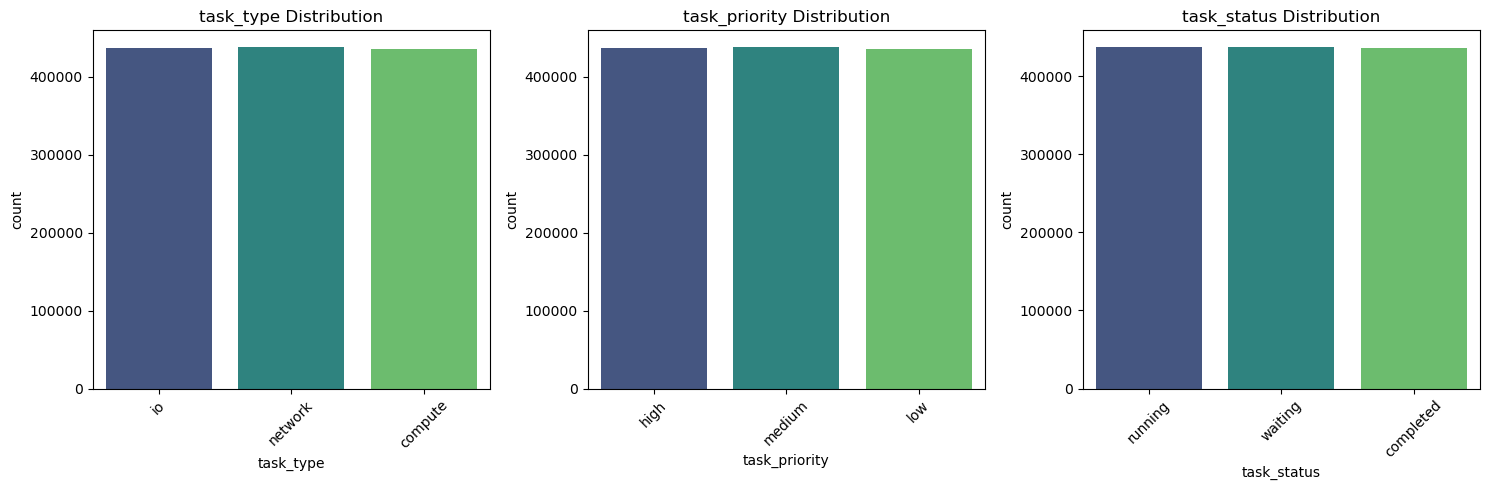

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ["task_type", "task_priority", "task_status"]

plt.figure(figsize=(15, 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df[col], data=df, palette="viridis")
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
categorical_cols = ["task_type", "task_priority", "task_status"]

for col in categorical_cols:
    # Eksik değer olan satırların indeksleri
    missing_indices = df[df[col].isnull()].index
    # Random sampling ile doldurma
    df.loc[missing_indices, col] = np.random.choice(df[col].dropna().unique(), size=len(missing_indices))

df["num_executed_instructions"].fillna(df["num_executed_instructions"].median(), inplace=True)


print("Eksik değerler kaldı mı?")
print(df.isnull().sum())

C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\3027332876.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["num_executed_instructions"].fillna(df["num_executed_instructions"].median(), inplace=True)


Eksik değerler kaldı mı?
vm_id                        0
timestamp                    0
cpu_usage                    0
memory_usage                 0
network_traffic              0
power_consumption            0
num_executed_instructions    0
execution_time               0
energy_efficiency            0
task_type                    0
task_priority                0
task_status                  0
hour_of_day                  0
day_of_week                  0
month_of_year                0
cpu_usage_7d_avg             0
memory_usage_7d_avg          0
dtype: int64


In [19]:
categorical_cols = ["task_type", "task_priority", "task_status"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())

                                        vm_id           timestamp  cpu_usage  memory_usage  network_traffic  power_consumption  num_executed_instructions  execution_time  energy_efficiency  hour_of_day  day_of_week  month_of_year  cpu_usage_7d_avg  memory_usage_7d_avg  task_type_io  task_type_network  task_priority_low  task_priority_medium  task_status_running  task_status_waiting
454771   a5ee77f0-5a60-474d-8a66-11bf38337326 2023-01-01 00:00:09     63.282        49.990          212.708            358.127                   3983.000          45.303              0.681            0            6              1            63.282               49.990          True              False              False                 False                 True                False
898414   fe5e04e3-4ea4-48cf-a193-3f58abd147ed 2023-01-01 00:00:31     14.020        74.367          600.521            368.736                   8240.000          50.742              0.640            0            6              1 

In [20]:
from sklearn.preprocessing import MinMaxScaler

# Numerik değişkenler
numerical_cols = [
    "memory_usage", "cpu_usage", "network_traffic", 
    "power_consumption", "num_executed_instructions", 
    "execution_time", "energy_efficiency"
]

# Min-Max Scaling işlemi
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Kontrol edelim
print(df.head())

                                        vm_id           timestamp  cpu_usage  memory_usage  network_traffic  power_consumption  num_executed_instructions  execution_time  energy_efficiency  hour_of_day  day_of_week  month_of_year  cpu_usage_7d_avg  memory_usage_7d_avg  task_type_io  task_type_network  task_priority_low  task_priority_medium  task_status_running  task_status_waiting
454771   a5ee77f0-5a60-474d-8a66-11bf38337326 2023-01-01 00:00:09      0.633         0.500            0.213              0.716                      0.398           0.453              0.681            0            6              1            63.282               49.990          True              False              False                 False                 True                False
898414   fe5e04e3-4ea4-48cf-a193-3f58abd147ed 2023-01-01 00:00:31      0.140         0.744            0.601              0.737                      0.824           0.507              0.640            0            6              1 

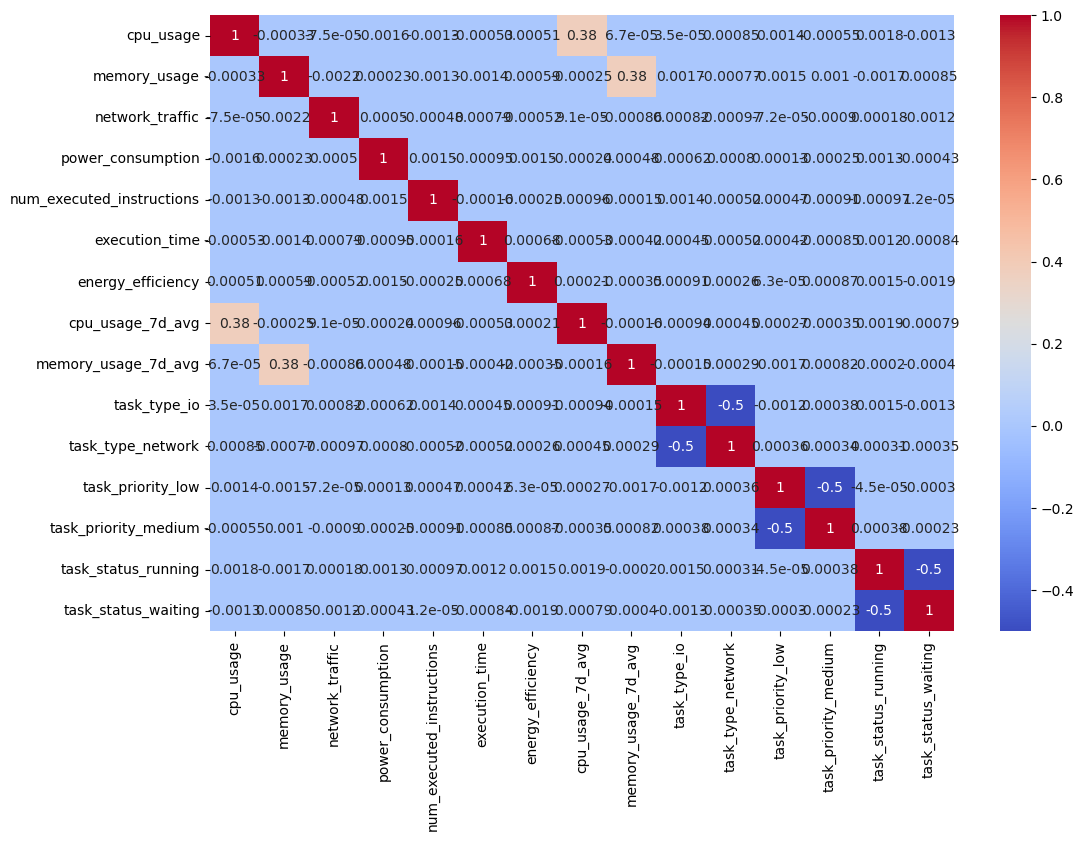

In [21]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool'])

# Korelasyon Matrisi Görselleştirme
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
df["memory_per_cpu"] = df["memory_usage"] / (df["cpu_usage"] + 1e-9)
df["energy_per_instruction"] = df["power_consumption"] / (df["num_executed_instructions"] + 1e-9)
df["efficiency_per_network"] = df["energy_efficiency"] / (df["network_traffic"] + 1e-9)
df["time_per_instruction"] = df["execution_time"] / (df["num_executed_instructions"] + 1e-9)

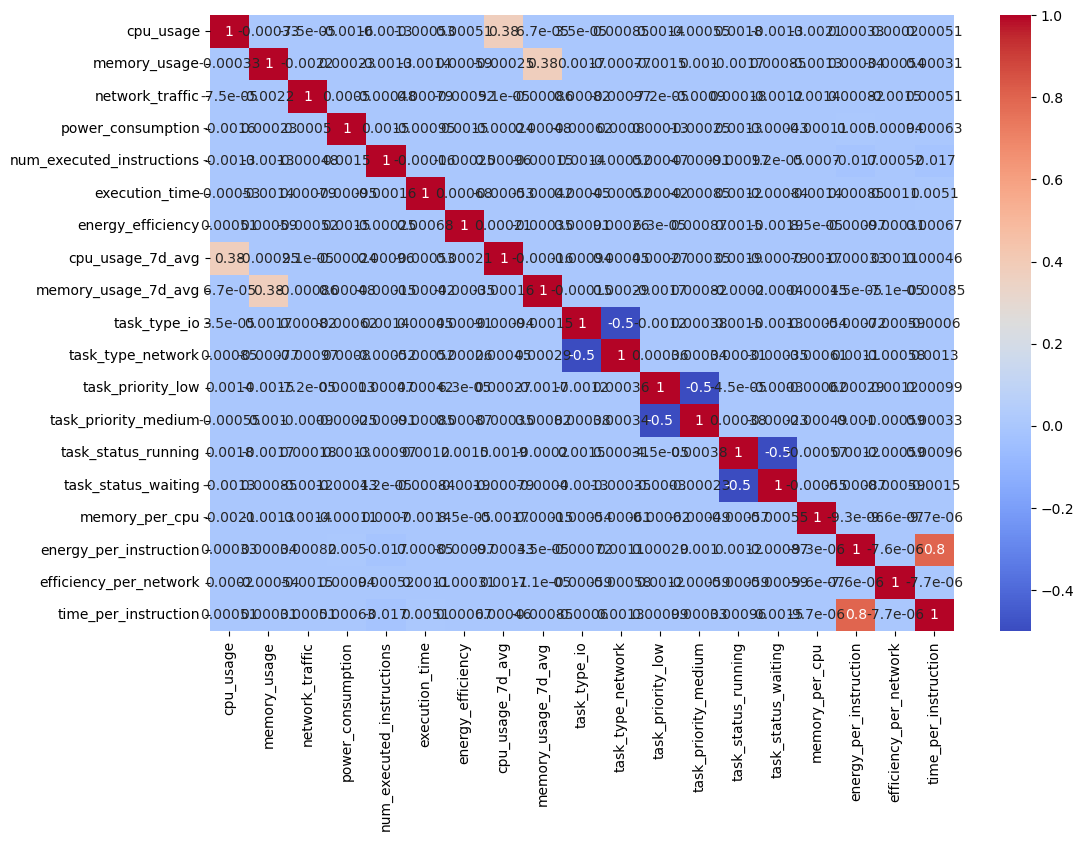

In [23]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool'])

# Korelasyon Matrisi Görselleştirme
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [24]:
df_sample = df.sample(frac=1, random_state=42)


y = df_sample["power_consumption"]
X = df_sample.drop(columns=["power_consumption", "vm_id", "timestamp"])

In [25]:
from sklearn.model_selection import train_test_split

# Eğitim ve test seti ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Eğitim Seti Boyutu: (1164372, 21)
Test Seti Boyutu: (291094, 21)


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# 🚀 Mini-Batch Training (RandomForest Regressor)
model = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 🎯 Tahminler
y_pred = model.predict(X_test)

# 📊 Başarı Değerlendirmesi
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"RMSE : {root_mean_squared_error (y_test, y_pred)}")

R2 Score: 0.9849976600383294
MAE : 0.012149230923590876
MSE : 0.0012531417122422068
RMSE : 0.03539974169739388


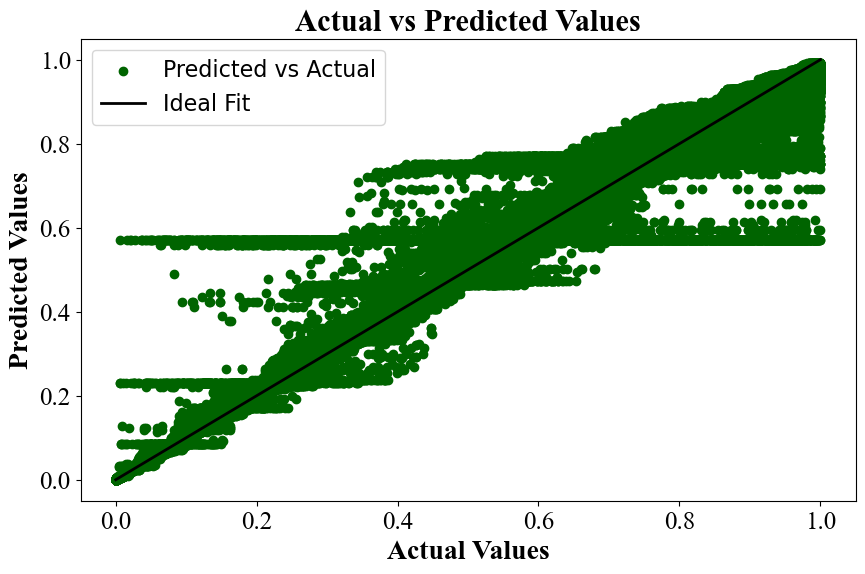

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='darkgreen', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='black', linewidth=2, label='Ideal Fit')

plt.title('Actual vs Predicted Values', fontsize=22, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Actual Values', fontsize=20, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Predicted Values', fontsize=20, fontname='Times New Roman', fontweight='bold')

plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')
plt.legend(fontsize=16)
plt.savefig("Actual vs Predicted Values.png")
plt.show()


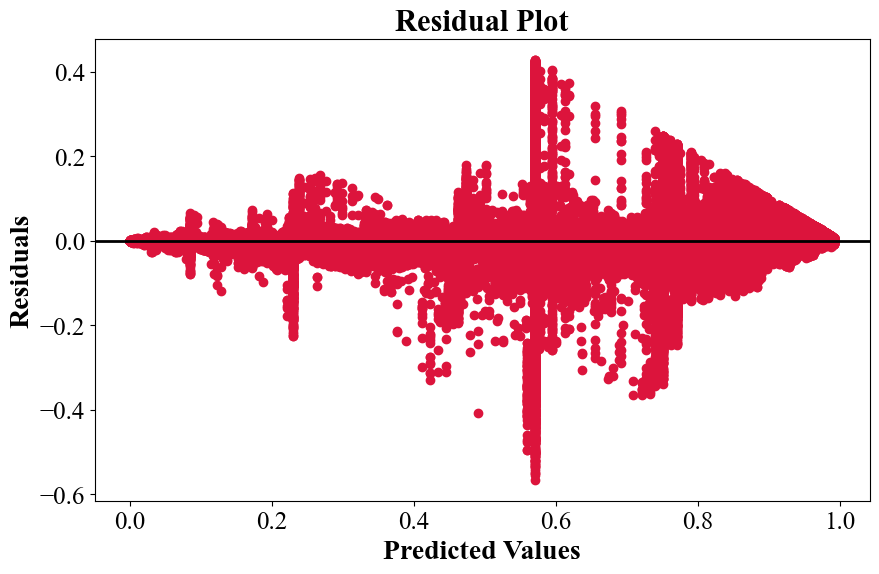

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, color='crimson')

plt.axhline(y=0, color='black', linewidth=2)

plt.title('Residual Plot', fontsize=22, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Predicted Values', fontsize=20, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Residuals', fontsize=20, fontname='Times New Roman', fontweight='bold')

plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')
plt.savefig("Residual Plot.png")
plt.show()


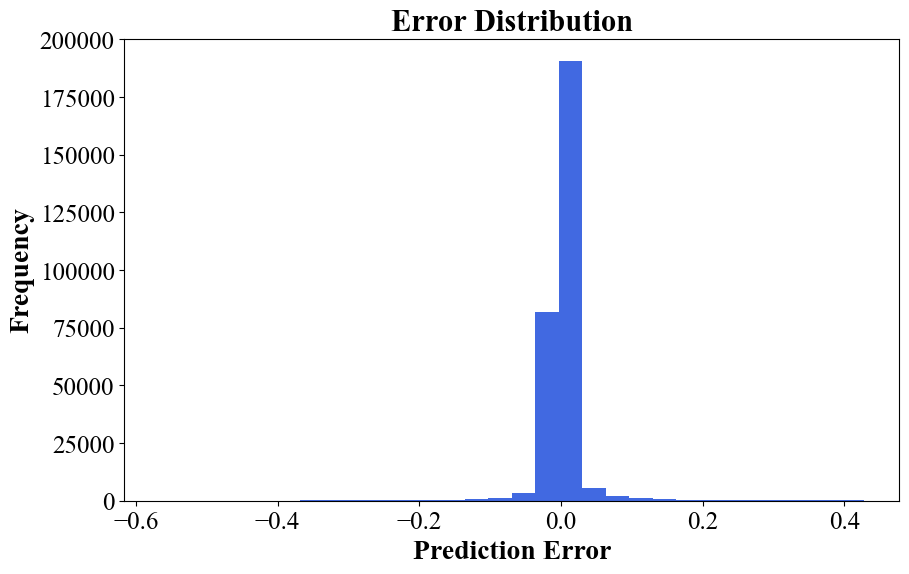

In [28]:
plt.figure(figsize=(10,6))
plt.hist(residuals, bins=30, color='royalblue')

plt.title('Error Distribution', fontsize=22, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Prediction Error', fontsize=20, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Frequency', fontsize=20, fontname='Times New Roman', fontweight='bold')

plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')
plt.savefig("Error Distribution.png")
plt.show()


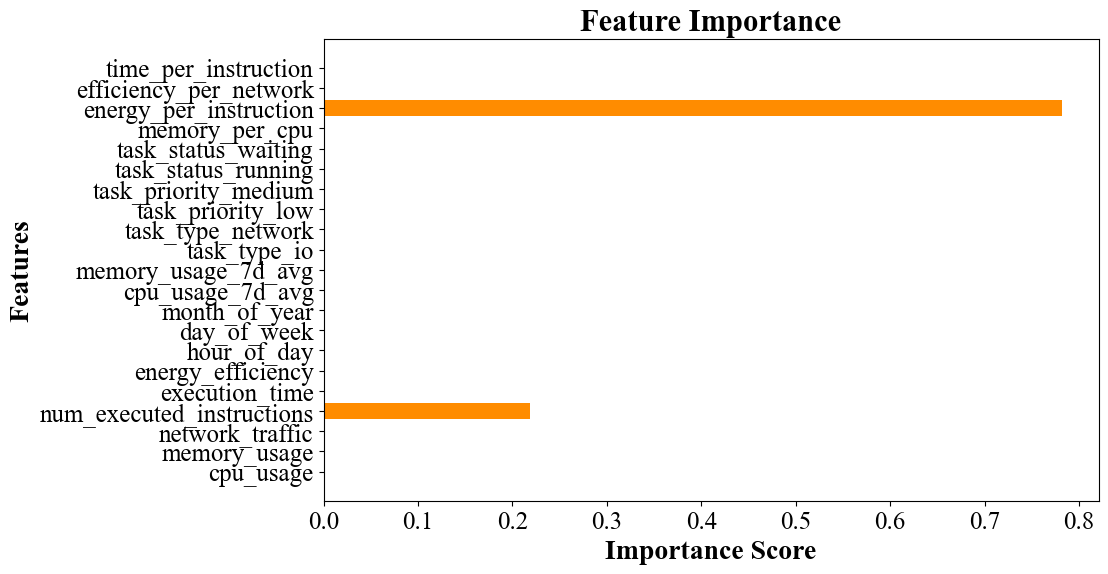

In [29]:
importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances, color='darkorange')

plt.title('Feature Importance', fontsize=22, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Importance Score', fontsize=20, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Features', fontsize=20, fontname='Times New Roman', fontweight='bold')

plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')
plt.savefig("Feature Importance.png")
plt.show()


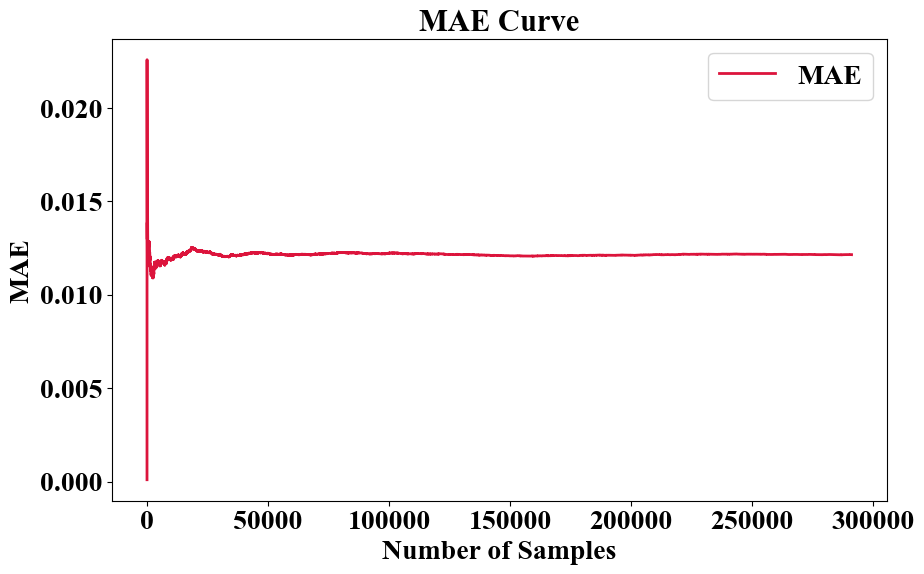

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Example: y_test and y_pred must be defined
# y_test = ...
# y_pred = ...

# Hataları biriktirmek için listeler oluşturuyoruz
mae_list = []
mse_list = []
rmse_list = []

# Örnek sayısına göre (1'den n'e kadar) hataları hesapla
for i in range(1, len(y_test) + 1):
    current_mae = mean_absolute_error(y_test[:i], y_pred[:i])
    current_mse = mean_squared_error(y_test[:i], y_pred[:i])
    current_rmse = np.sqrt(current_mse)
    
    mae_list.append(current_mae)
    mse_list.append(current_mse)
    rmse_list.append(current_rmse)

# Font settings
font_title = {'family': 'Times New Roman', 'weight': 'bold', 'size': 22}
font_labels = {'family': 'Times New Roman', 'weight': 'bold', 'size': 20}
font_ticks = {'family': 'Times New Roman', 'weight': 'bold', 'size': 20}
font_legend = {'family': 'Times New Roman', 'weight': 'bold', 'size': 20}

# ------------------------------
# MAE Curve
plt.figure(figsize=(10, 6))
plt.plot(mae_list, color='crimson', label='MAE', linewidth=2)
plt.title('MAE Curve', **font_title)
plt.xlabel('Number of Samples', **font_labels)
plt.ylabel('MAE', **font_labels)
plt.xticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.yticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.legend(prop=font_legend)
plt.savefig('MAE Curve.png')
plt.show()


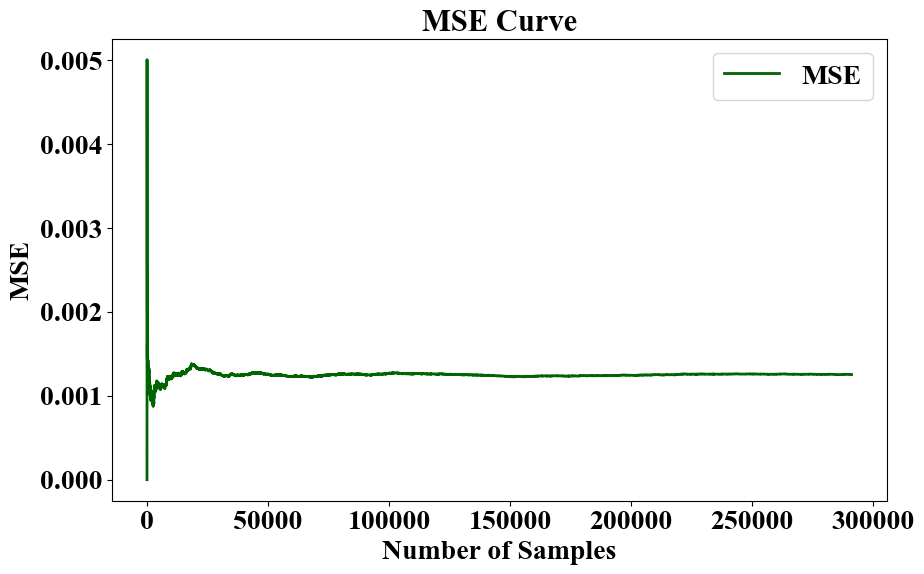

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(mse_list, color='darkgreen', label='MSE', linewidth=2)
plt.title('MSE Curve', **font_title)
plt.xlabel('Number of Samples', **font_labels)
plt.ylabel('MSE', **font_labels)
plt.xticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.yticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.legend(prop=font_legend)
plt.savefig('MSE Curve.png')
plt.show()

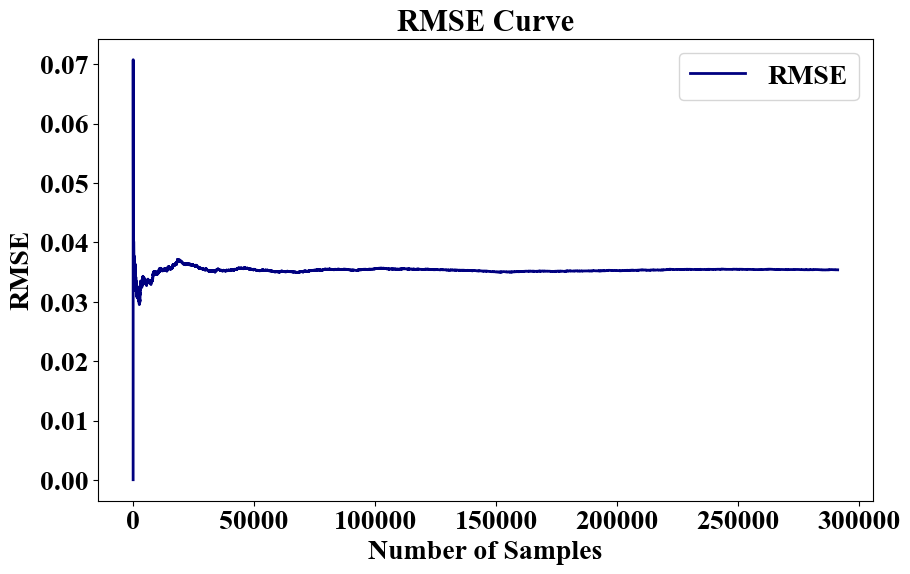

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(rmse_list, color='navy', label='RMSE', linewidth=2)
plt.title('RMSE Curve', **font_title)
plt.xlabel('Number of Samples', **font_labels)
plt.ylabel('RMSE', **font_labels)
plt.xticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.yticks(fontsize=font_ticks['size'], fontweight=font_ticks['weight'], fontname=font_ticks['family'])
plt.legend(prop=font_legend)
plt.savefig('RMSE Curve.png')
plt.show()

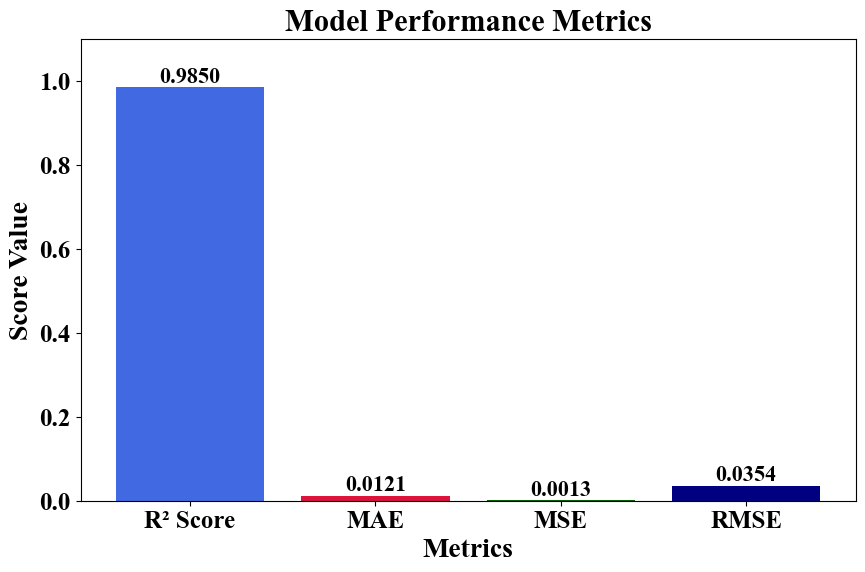

In [36]:
import matplotlib.pyplot as plt

# Metric names and values
metrics = ['R² Score', 'MAE', 'MSE', 'RMSE']
values = [
    0.9849976600383294,
    0.012149230923590876,
    0.0012531417122422068,
    0.03539974169739388
]

# Colors for each bar
colors = ['royalblue', 'crimson', 'darkgreen', 'navy']

# Font settings
plt.figure(figsize=(10, 6))

bars = plt.bar(metrics, values, color=colors)

plt.title('Model Performance Metrics', 
          fontname='Times New Roman', fontsize=22, fontweight='bold')

plt.xlabel('Metrics', 
           fontname='Times New Roman', fontsize=20, fontweight='bold')

plt.ylabel('Score Value', 
           fontname='Times New Roman', fontsize=20, fontweight='bold')

plt.xticks(fontsize=18, fontname='Times New Roman', fontweight='bold')
plt.yticks(fontsize=18, fontname='Times New Roman', fontweight='bold')
plt.ylim(0,1.1)
# Value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=16,
        fontname='Times New Roman',
        fontweight='bold'
    )
plt.savefig('Model Performance Metrics.png')
plt.show()